# Credit Risk Scorecard Model

## Objective
Predict loan default risk using logistic regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
columns = [
    "checking_account", "duration", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment_since",
    "installment_rate", "personal_status", "other_debtors",
    "residence_since", "property", "age", "other_installment_plans",
    "housing", "existing_credits", "job", "num_dependents",
    "telephone", "foreign_worker", "target"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

df = pd.read_csv(url, sep=' ', names=columns)
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
df['target'] = df['target'].apply(lambda x: 1 if x == 2 else 0)

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_since         1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status          1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


## Data Preprocessing
Encoding categorical variables for model training

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000, solver='liblinear')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [8]:
y_pred_proba = model.predict_proba(X_test)[:,1]

In [9]:
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)

AUC: 0.817393133182607


## Model Evaluation
ROC-AUC measures how well the model distinguishes between good and bad customers

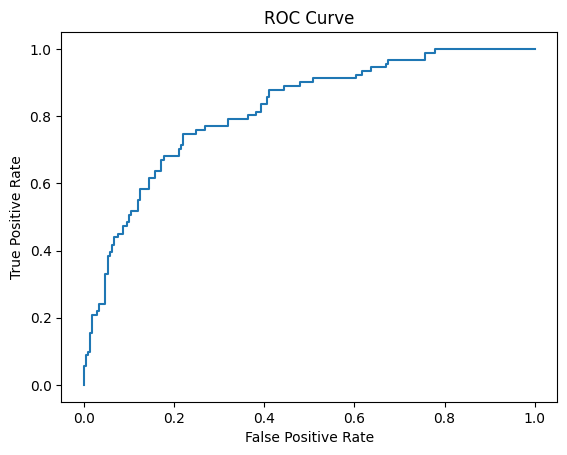

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [11]:
def ks_stat(y_true, y_pred):
    data = pd.DataFrame({'y': y_true, 'prob': y_pred})
    data = data.sort_values(by='prob')
    
    data['cum_good'] = (data['y']==0).cumsum() / (data['y']==0).sum()
    data['cum_bad'] = (data['y']==1).cumsum() / (data['y']==1).sum()
    
    return max(abs(data['cum_good'] - data['cum_bad']))

ks = ks_stat(y_test, y_pred_proba)
print("KS Statistic:", ks)

KS Statistic: 0.5271570534728429


In [12]:
importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', ascending=False)

importance.head(10)

,feature,coefficient
2,installment_rate,0.375212
1,credit_amount,0.363809
38,property_A124,0.265933
0,duration,0.234276
44,job_A173,0.196705
5,existing_credits,0.189074
36,property_A122,0.179089
45,job_A174,0.162015
43,job_A172,0.143885
37,property_A123,0.112672


In [13]:
credit_score = 300 + (y_pred_proba * 600)

score_df = pd.DataFrame({
    'Probability': y_pred_proba,
    'Credit Score': credit_score
})

score_df.head()

,Probability,Credit Score
0,0.399116,539.469746
1,0.537959,622.775221
2,0.638392,683.034918
3,0.302753,481.652016
4,0.041893,325.135613


## Conclusion

- Built a credit risk model using logistic regression  
- Evaluated using ROC-AUC and KS statistic  
- Generated credit score for decision-making  

### Business Impact
This model helps banks identify high-risk customers and make better lending decisions.